# 09-01. Model A — Next-season Big5 Presence Classifier
## 다음 시즌에도 Big 5 리그 기록이 존재하는가?

---

# Two-stage 구조

지금까지의 회귀 Model B는:

> **다음 시즌에도 Big5 기록이 존재하는 선수(`matched_next=True`)의 다음 시즌 득점 수**

를 예측했습니다.

하지만 실제 preseason에서는 어떤 선수가:

- Big5에 계속 남는지
- Big5 밖으로 이적하는지
- 은퇴/방출/미등록 등으로 Big5 기록이 사라지는지

를 미리 알 수 없습니다.

따라서 전체 문제를 두 단계로 나눕니다.

```text
Model A
P(다음 시즌 Big5 기록 존재)

          ↓

Model B
E(다음 시즌 득점 | Big5 기록 존재)

          ↓

09-02에서 결합
P(Big5 존재) × 조건부 득점 예측
```

---

# 이번 Notebook의 목표

이번 09-01에서는 **Model A만 검증**합니다.

Target:

```text
matched_next = 1
→ 다음 시즌 Big5 데이터에 선수 기록 존재

matched_next = 0
→ 다음 시즌 Big5 데이터에 선수 기록 없음
```

중요:

> `matched_next=False`는 "같은 팀에서 이탈"이라는 뜻이 아닙니다.

다른 Big5 팀으로 이동했다면 `matched_next=True`일 수 있습니다.

따라서 Model A의 정확한 의미는:

> **Next-season Big5 Presence**

입니다.

---

# 평가에서 Accuracy만 보면 안 되는 이유

2017+ 데이터에서는 `matched_next=True`가 약 84%입니다.

따라서 전부 True라고 예측해도 Accuracy가 높게 보일 수 있습니다.

이번에는 다음을 같이 봅니다.

### 확률 품질 — Two-stage에서 특히 중요
- Log Loss
- Brier Score
- ROC-AUC
- PR-AUC
- Exit PR-AUC (`matched_next=False` 관점)

### Threshold 분류
- Balanced Accuracy
- Macro F1
- Big5 Presence Recall
- Big5 Exit Recall

Threshold는 Outer Validation에서 고르지 않습니다.

각 Outer Train의 마지막 시즌을 calibration validation으로 사용해
Macro F1 기준 threshold를 결정한 뒤 Outer Validation을 단 한 번 평가합니다.

---

# 비교 모델

```text
1. Naive Prevalence
2. Logistic Regression
3. CatBoost Classifier
```

이번 단계에서는 HPO하지 않습니다.

Model A 자체의 난이도와 외부 피처의 유효성을 먼저 확인합니다.

## 0. 실행 환경

이 Notebook은:

- 로컬 VS Code
- VS Code + Colab GPU
- 브라우저 Google Colab

모두 사용할 수 있게 구성합니다.

Google Drive가 이미 mount되어 있으면:

```text
/content/drive/MyDrive/next_season_goal_prediction/artifacts
```

를 우선 사용합니다.

그 외에는 현재 작업 폴더에서 자동 탐색합니다.

In [6]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
from pathlib import Path

p = Path(
    "/content/drive/MyDrive/next_season_goal_prediction/artifacts/"
    "08_v2_preseason_player_snapshot_dev.csv"
)

print(p.exists())

False


In [8]:
from pathlib import Path
import json
import random
import subprocess
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Seed:", SEED)

Seed: 42


## 1. CatBoost / GPU 확인

CatBoost가 없으면 Colab 환경에서는 자동 설치합니다.

GPU가 확인되면 CatBoost가 GPU를 사용하고,
그 외에는 CPU로 fallback합니다.

In [9]:
try:
    import catboost
    from catboost import CatBoostClassifier

except ImportError:
    print(
        "catboost가 없어 설치합니다..."
    )

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "catboost",
        ]
    )

    import catboost
    from catboost import CatBoostClassifier


try:
    import torch

    USE_GPU = bool(
        torch.cuda.is_available()
    )

except ImportError:
    USE_GPU = False


CATBOOST_DEVICE_PARAMS = (
    {
        "task_type": "GPU",
        "devices": "0",
    }
    if USE_GPU
    else {
        "task_type": "CPU",
    }
)

print(
    "catboost:",
    catboost.__version__,
)

print(
    "GPU:",
    USE_GPU,
)

print(
    "CatBoost device:",
    CATBOOST_DEVICE_PARAMS,
)

catboost: 1.2.10
GPU: True
CatBoost device: {'task_type': 'GPU', 'devices': '0'}


# Part A. 데이터 로드

## 2. Snapshot 탐색

필수 파일:

```text
08_v2_preseason_player_snapshot_dev.csv
```

이 파일은 08-01 v2에서 leakage-safe preseason cutoff를 기준으로 만든 개발 snapshot입니다.

In [10]:
MANUAL_SNAPSHOT_PATH = None

DRIVE_ARTIFACT_DIR = Path(
    "/content/drive/MyDrive/"
    "next_season_goal_prediction/"
    "artifacts"
)

LOCAL_SEARCH_ROOTS = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
]


def find_snapshot():
    if (
        DRIVE_ARTIFACT_DIR.exists()
        and (
            DRIVE_ARTIFACT_DIR
            / "08_v2_preseason_player_snapshot_dev.csv"
        ).exists()
    ):
        return (
            DRIVE_ARTIFACT_DIR
            / "08_v2_preseason_player_snapshot_dev.csv"
        )

    candidates = []

    for root in (
        LOCAL_SEARCH_ROOTS
    ):
        if not root.exists():
            continue

        try:
            for path in root.rglob(
                "08_v2_preseason_player_snapshot_dev.csv"
            ):
                if path.is_file():
                    candidates.append(
                        path
                    )

        except (
            PermissionError,
            OSError,
        ):
            continue

    if not candidates:
        return None

    candidates.sort(
        key=lambda p: (
            len(str(p)),
            str(p),
        )
    )

    return candidates[0]


if (
    MANUAL_SNAPSHOT_PATH
    is not None
):
    SNAPSHOT_PATH = Path(
        MANUAL_SNAPSHOT_PATH
    )

else:
    SNAPSHOT_PATH = (
        find_snapshot()
    )


if (
    SNAPSHOT_PATH is None
    or not SNAPSHOT_PATH.exists()
):
    raise FileNotFoundError(
        "08_v2_preseason_player_snapshot_dev.csv를 "
        "찾지 못했습니다."
    )


if (
    str(SNAPSHOT_PATH).startswith(
        "/content/drive/"
    )
):
    ARTIFACT_DIR = (
        SNAPSHOT_PATH.parent
    )

else:
    ARTIFACT_DIR = Path(
        "artifacts"
    )

    ARTIFACT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )


print(
    "Snapshot:",
    SNAPSHOT_PATH,
)

print(
    "Output:",
    ARTIFACT_DIR.resolve(),
)

Snapshot: /content/drive/MyDrive/next_season_goal_prediction (1)/artifacts/08_v2_preseason_player_snapshot_dev.csv
Output: /content/drive/MyDrive/next_season_goal_prediction (1)/artifacts


In [11]:
df = pd.read_csv(
    SNAPSHOT_PATH,
    low_memory=False,
)

print(
    "Shape:",
    df.shape,
)

print(
    "Columns:",
    len(
        df.columns
    ),
)

display(
    df[
        [
            "player",
            "team",
            "league",
            "season",
            "target_season",
            "matched_next",
            "goals",
            "next_goals",
        ]
    ].head()
)

Shape: (23353, 114)
Columns: 114


,player,team,league,season,target_season,matched_next,goals,next_goals
0,Abdelhafid Tasfaout,Guingamp,Ligue 1,2000-2001,2001-2002,True,5.0,1.0
1,Abder Ramdane,Freiburg,Bundesliga,2000-2001,2001-2002,True,3.0,0.0
2,Adaílton,Hellas Verona,Serie A,2000-2001,2001-2002,True,4.0,1.0
3,Ade Akinbiyi,Leicester City,Premier League,2000-2001,2001-2002,True,9.0,2.0
4,Adel Sellimi,Freiburg,Bundesliga,2000-2001,2001-2002,True,10.0,5.0


## 3. Final Test Lock

09-01에서도 Final Test는 사용하지 않습니다.

```text
2024-25 → 2025-26
```

In [12]:
LOCKED_TEST_INPUT_SEASON = (
    "2024-2025"
)

LOCKED_TEST_TARGET_SEASON = (
    "2025-2026"
)

assert (
    LOCKED_TEST_INPUT_SEASON
    not in set(
        df[
            "season"
        ].astype(str)
    )
)

print(
    "✅ Final Test locked:",
    LOCKED_TEST_INPUT_SEASON,
    "→",
    LOCKED_TEST_TARGET_SEASON,
)

✅ Final Test locked: 2024-2025 → 2025-2026


# Part B. Feature 재생성

## 4. Exp9Cb historical scoring feature

08 단계와 동일하게 `shift(1)`을 사용합니다.

현재 row의 과거 3시즌 기록만 rolling history에 사용됩니다.

In [13]:
df[
    "season_start"
] = (
    df["season"]
    .astype(str)
    .str[:4]
    .astype(int)
)

df[
    "target_year"
] = (
    df[
        "target_season"
    ]
    .astype(str)
    .str[:4]
    .astype(int)
)

df = (
    df
    .sort_values(
        [
            "player",
            "season_start",
        ]
    )
    .reset_index(
        drop=True
    )
)

player_group = (
    df.groupby(
        "player",
        sort=False,
    )
)

df[
    "goals_3yr_mean"
] = player_group[
    "goals"
].transform(
    lambda s:
        s.shift(1)
        .rolling(
            window=3,
            min_periods=1,
        )
        .mean()
)

df[
    "goals_per90_3yr_mean"
] = player_group[
    "goals_per90"
].transform(
    lambda s:
        s.shift(1)
        .rolling(
            window=3,
            min_periods=1,
        )
        .mean()
)

df[
    "goals_3yr_max"
] = player_group[
    "goals"
].transform(
    lambda s:
        s.shift(1)
        .rolling(
            window=3,
            min_periods=1,
        )
        .max()
)

HISTORICAL_COLS = [
    "goals_3yr_mean",
    "goals_per90_3yr_mean",
    "goals_3yr_max",
]

df[
    HISTORICAL_COLS
] = (
    df[
        HISTORICAL_COLS
    ]
    .fillna(0.0)
)

## 5. Model A 개발기간 — 2017+

Transfer exact-date coverage가 오래된 시즌에서 낮았기 때문에
08 단계와 동일하게 `target_year >= 2017`을 사용합니다.

Model B와 다른 점은:

```text
Model B
matched_next=True만 사용

Model A
matched_next=True/False 모두 사용
```

입니다.

In [14]:
model_a_df = (
    df[
        df[
            "target_year"
        ].ge(2017)
    ]
    .copy()
)

model_a_df[
    "target_presence"
] = (
    model_a_df[
        "matched_next"
    ]
    .astype(int)
)

model_a_df = (
    model_a_df
    .sort_values(
        [
            "season_start",
            "player",
        ]
    )
    .reset_index(
        drop=True
    )
)

print(
    "Model A rows:",
    len(model_a_df),
)

print(
    "Presence rate:",
    f"{model_a_df['target_presence'].mean():.2%}"
)

print(
    "Exit / no-Big5 rate:",
    f"{1 - model_a_df['target_presence'].mean():.2%}"
)

Model A rows: 7572
Presence rate: 84.14%
Exit / no-Big5 rate: 15.86%


## 6. 시즌별 Class Balance

Accuracy가 왜 위험한 지표인지 먼저 확인합니다.

In [15]:
class_balance = (
    model_a_df
    .groupby(
        "season"
    )
    .agg(
        n=(
            "target_presence",
            "size",
        ),
        presence_n=(
            "target_presence",
            "sum",
        ),
        presence_rate=(
            "target_presence",
            "mean",
        ),
    )
)

class_balance[
    "exit_n"
] = (
    class_balance[
        "n"
    ]
    - class_balance[
        "presence_n"
    ]
)

class_balance[
    "exit_rate"
] = (
    1
    - class_balance[
        "presence_rate"
    ]
)

class_balance

,n,presence_n,presence_rate,exit_n,exit_rate
season,,,,,
2016-2017,993,832,0.837865,161,0.162135
2017-2018,954,825,0.864780,129,0.135220
2018-2019,956,807,0.844142,149,0.155858
2019-2020,914,788,0.862144,126,0.137856
2020-2021,960,834,0.868750,126,0.131250
2021-2022,934,778,0.832976,156,0.167024
2022-2023,938,738,0.786780,200,0.213220
2023-2024,923,769,0.833153,154,0.166847


# Part C. Model A Feature Set

## 7. Feature 정책

08-03에서 확정한 **S3 Selected External**을 기본으로 사용합니다.

추가로 Model A에서만 직접적인 의미가 있는 preseason-known 정보를 두 개 추가합니다.

```text
transfer_event_preseason
destination_in_big5
```

왜 가능한가?

둘 다 08-01의 prediction cutoff 이전에 확인된 정보로만 생성됐기 때문입니다.

`destination_in_big5`는:

- confirmed transfer destination이 Big5인지
- 팀 변경이 없다면 현재 Big5 league를 유지하는지

를 나타냅니다.

### 사용하지 않는 것

```text
matched_next
next_goals
next_10plus
미래 시즌 성적
post-cutoff transfer audit
unknown-date future transfer audit
```

In [16]:
BASE_NUMERIC = [
    "age",
    "starts",
    "minutes",
    "goals",
    "assists",
    "non_penalty_goals",
    "penalty_goals",
    "penalty_attempts",
    "goals_per90",
    "assists_per90",
    "goal_contrib_per90",
]

TEAM_BASE_FEATURES = [
    "old_team_rank_pct",
    "old_team_points_per_game",
    "old_team_goal_diff_per_game",
]

MARKET_VALUE_FEATURES = [
    "market_value_known",
    "log_market_value",
    "market_value_percentile",
    "market_value_vs_position_median",
]

MARKET_MOMENTUM_FEATURES = [
    "market_value_growth_6m",
    "market_value_growth_12m",
    "market_value_vs_peak",
]

TRANSFER_STATE_FEATURES = [
    "changed_team_preseason",
    "same_league_transfer",
    "league_changed",
    "country_changed",
    "is_loan_preseason",
    "days_since_transfer",
]

NEW_TEAM_ENVIRONMENT_FEATURES = [
    "new_team_prev_rank_pct",
    "new_team_prev_points_per_game",
    "new_team_prev_goal_diff_per_game",
    "team_rank_change",
    "team_points_change",
    "team_goal_diff_change",
    "new_team_strength_missing",
]

MODEL_A_SPECIFIC_FEATURES = [
    "transfer_event_preseason",
    "destination_in_big5",
]

MODEL_A_NUMERIC = (
    BASE_NUMERIC
    + HISTORICAL_COLS
    + TEAM_BASE_FEATURES
    + MARKET_VALUE_FEATURES
    + MARKET_MOMENTUM_FEATURES
    + TRANSFER_STATE_FEATURES
    + NEW_TEAM_ENVIRONMENT_FEATURES
    + MODEL_A_SPECIFIC_FEATURES
)

MODEL_A_CATEGORICAL = [
    "league",
    "position_group",
]

MODEL_A_FEATURES = (
    MODEL_A_NUMERIC
    + MODEL_A_CATEGORICAL
)

TARGET = (
    "target_presence"
)

print(
    "Numeric:",
    len(
        MODEL_A_NUMERIC
    ),
)

print(
    "Categorical:",
    MODEL_A_CATEGORICAL,
)

print(
    "Total raw features:",
    len(
        MODEL_A_FEATURES
    ),
)

Numeric: 39
Categorical: ['league', 'position_group']
Total raw features: 41


## 8. Leakage 방지 Assertion

In [17]:
FORBIDDEN_FEATURES = {
    "matched_next",
    "next_goals",
    "next_10plus",
    "target_presence",
    "unknown_date_context_event_count_audit",
    "post_cutoff_context_event_count_audit",
}

overlap = (
    FORBIDDEN_FEATURES
    & set(
        MODEL_A_FEATURES
    )
)

assert not overlap, (
    f"Forbidden feature detected: {overlap}"
)

# Point-in-time transfer 날짜 재검증
model_a_df[
    "cutoff_date"
] = pd.to_datetime(
    model_a_df[
        "cutoff_date"
    ],
    errors="coerce",
)

model_a_df[
    "transfer_date_preseason"
] = pd.to_datetime(
    model_a_df[
        "transfer_date_preseason"
    ],
    errors="coerce",
)

dated_transfer_mask = (
    model_a_df[
        "transfer_date_preseason"
    ].notna()
)

assert (
    model_a_df.loc[
        dated_transfer_mask,
        "transfer_date_preseason",
    ]
    <= model_a_df.loc[
        dated_transfer_mask,
        "cutoff_date",
    ]
).all(), (
    "LEAKAGE: cutoff 이후 transfer가 "
    "Model A snapshot에 포함되었습니다."
)

print(
    "✅ Forbidden target/future columns are not used."
)

print(
    "✅ All dated preseason transfers are on/before cutoff."
)

✅ Forbidden target/future columns are not used.
✅ All dated preseason transfers are on/before cutoff.


## 9. Missingness

In [18]:
missingness = (
    model_a_df[
        MODEL_A_NUMERIC
    ]
    .isna()
    .mean()
    .sort_values(
        ascending=False
    )
    .rename(
        "missing_rate"
    )
    .to_frame()
)

display(
    missingness.head(20)
)

,missing_rate
days_since_transfer,0.874274
market_value_growth_12m,0.061939
market_value_growth_6m,0.057845
market_value_vs_position_median,0.057448
market_value_vs_peak,0.057448
log_market_value,0.057448
market_value_percentile,0.057448
new_team_prev_points_per_game,0.045959
new_team_prev_goal_diff_per_game,0.045959
team_rank_change,0.045959


# Part D. Temporal Evaluation

## 10. Outer Walk-forward Fold

Model B와 동일한 개발 평가기간을 유지합니다.

```text
Fold 1: Val 2020-21
Fold 2: Val 2021-22
Fold 3: Val 2022-23
Fold 4: Val 2023-24
```

In [19]:
OUTER_VAL_SEASONS = [
    "2020-2021",
    "2021-2022",
    "2022-2023",
    "2023-2024",
]

for fold_id, val_season in enumerate(
    OUTER_VAL_SEASONS,
    start=1,
):
    val_start = int(
        val_season[:4]
    )

    train_part = (
        model_a_df[
            model_a_df[
                "season_start"
            ]
            < val_start
        ]
    )

    val_part = (
        model_a_df[
            model_a_df[
                "season_start"
            ]
            == val_start
        ]
    )

    print(
        f"Fold {fold_id} | "
        f"Val {val_season} | "
        f"Train {len(train_part):,} | "
        f"Val {len(val_part):,} | "
        f"Val presence {val_part[TARGET].mean():.2%}"
    )

Fold 1 | Val 2020-2021 | Train 3,817 | Val 960 | Val presence 86.88%
Fold 2 | Val 2021-2022 | Train 4,777 | Val 934 | Val presence 83.30%
Fold 3 | Val 2022-2023 | Train 5,711 | Val 938 | Val presence 78.68%
Fold 4 | Val 2023-2024 | Train 6,649 | Val 923 | Val presence 83.32%


# Part E. Evaluation 함수

## 11. Probability Metrics

Two-stage에서는 hard class보다:

```text
P(Big5 presence)
```

그 자체를 사용하게 됩니다.

그래서 `Log Loss`, `Brier Score`를 중요하게 봅니다.

또 0 class가 적기 때문에:

```text
Exit PR-AUC
= matched_next=False를 positive event처럼 뒤집어 평가
```

도 같이 봅니다.

In [20]:
def probability_metrics(
    y_true,
    prob_presence,
):
    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    p = np.asarray(
        prob_presence,
        dtype=float,
    )

    p = np.clip(
        p,
        1e-7,
        1 - 1e-7,
    )

    return {
        "log_loss": (
            log_loss(
                y_true,
                p,
                labels=[
                    0,
                    1,
                ],
            )
        ),

        "brier": (
            brier_score_loss(
                y_true,
                p,
            )
        ),

        "roc_auc": (
            roc_auc_score(
                y_true,
                p,
            )
        ),

        "pr_auc_presence": (
            average_precision_score(
                y_true,
                p,
            )
        ),

        "pr_auc_exit": (
            average_precision_score(
                1 - y_true,
                1 - p,
            )
        ),
    }

## 12. Threshold Metrics

In [21]:
def threshold_metrics(
    y_true,
    prob_presence,
    threshold,
):
    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    pred = (
        np.asarray(
            prob_presence
        )
        >= threshold
    ).astype(int)

    (
        precision,
        recall,
        f1,
        support,
    ) = (
        precision_recall_fscore_support(
            y_true,
            pred,
            labels=[
                0,
                1,
            ],
            zero_division=0,
        )
    )

    cm = confusion_matrix(
        y_true,
        pred,
        labels=[
            0,
            1,
        ],
    )

    return {
        "threshold": float(
            threshold
        ),

        "accuracy": (
            accuracy_score(
                y_true,
                pred,
            )
        ),

        "balanced_accuracy": (
            balanced_accuracy_score(
                y_true,
                pred,
            )
        ),

        "macro_f1": (
            f1_score(
                y_true,
                pred,
                average="macro",
                zero_division=0,
            )
        ),

        "exit_precision": (
            precision[0]
        ),

        "exit_recall": (
            recall[0]
        ),

        "exit_f1": (
            f1[0]
        ),

        "presence_precision": (
            precision[1]
        ),

        "presence_recall": (
            recall[1]
        ),

        "presence_f1": (
            f1[1]
        ),

        "tn": int(
            cm[0, 0]
        ),

        "fp": int(
            cm[0, 1]
        ),

        "fn": int(
            cm[1, 0]
        ),

        "tp": int(
            cm[1, 1]
        ),
    }

## 13. Threshold 선택

Threshold는 Outer Validation에서 고르지 않습니다.

각 Outer Train의 마지막 시즌 prediction으로
Macro F1이 가장 높은 threshold를 선택합니다.

In [22]:
THRESHOLD_GRID = np.round(
    np.arange(
        0.20,
        0.951,
        0.01,
    ),
    2,
)


def choose_threshold(
    y_true,
    prob_presence,
):
    rows = []

    for threshold in (
        THRESHOLD_GRID
    ):
        m = threshold_metrics(
            y_true,
            prob_presence,
            threshold,
        )

        rows.append(
            m
        )

    table = pd.DataFrame(
        rows
    )

    best = (
        table
        .sort_values(
            [
                "macro_f1",
                "balanced_accuracy",
                "presence_recall",
            ],
            ascending=[
                False,
                False,
                False,
            ],
        )
        .iloc[0]
    )

    return (
        float(
            best[
                "threshold"
            ]
        ),
        table,
    )

# Part F. Naive Baseline

## 14. Naive Prevalence

확률 예측:

```text
P(Big5 presence)
= Outer Train의 presence 비율
```

Hard prediction에서는 거의 항상 1이 될 것입니다.

이 baseline은 class imbalance 때문에 Accuracy가 얼마나 오해를 줄 수 있는지 보여줍니다.

In [23]:
def predict_naive(
    outer_train_df,
    outer_val_df,
):
    prevalence = float(
        outer_train_df[
            TARGET
        ].mean()
    )

    prob = np.full(
        len(
            outer_val_df
        ),
        prevalence,
        dtype=float,
    )

    return {
        "prob": prob,
        "threshold": 0.5,
        "selected_rounds": np.nan,
        "train_prevalence": (
            prevalence
        ),
    }

# Part G. Logistic Regression

## 15. Logistic 전처리

Numeric:

```text
Train median
→ StandardScaler
```

Categorical:

```text
OneHotEncoder
```

In [24]:
def make_logistic_pipeline():
    numeric_pipeline = (
        Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    ),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
            ]
        )
    )

    preprocessor = (
        ColumnTransformer(
            transformers=[
                (
                    "num",
                    numeric_pipeline,
                    MODEL_A_NUMERIC,
                ),
                (
                    "cat",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False,
                    ),
                    MODEL_A_CATEGORICAL,
                ),
            ],
            remainder="drop",
        )
    )

    classifier = (
        LogisticRegression(
            C=1.0,
            max_iter=3000,
            random_state=SEED,
        )
    )

    return Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "classifier",
                classifier,
            ),
        ]
    )

## 16. Logistic threshold calibration + Outer fit

In [25]:
def split_calibration(
    outer_train_df,
):
    calibration_val_start = (
        outer_train_df[
            "season_start"
        ].max()
    )

    cal_train = (
        outer_train_df[
            outer_train_df[
                "season_start"
            ]
            < calibration_val_start
        ]
        .copy()
    )

    cal_val = (
        outer_train_df[
            outer_train_df[
                "season_start"
            ]
            == calibration_val_start
        ]
        .copy()
    )

    if (
        cal_train.empty
        or cal_val.empty
    ):
        raise ValueError(
            "Calibration split 생성 실패"
        )

    return (
        cal_train,
        cal_val,
    )


def fit_logistic_outer(
    outer_train_df,
    outer_val_df,
):
    (
        cal_train,
        cal_val,
    ) = split_calibration(
        outer_train_df
    )

    selector = (
        make_logistic_pipeline()
    )

    selector.fit(
        cal_train[
            MODEL_A_FEATURES
        ],
        cal_train[
            TARGET
        ],
    )

    cal_prob = (
        selector.predict_proba(
            cal_val[
                MODEL_A_FEATURES
            ]
        )[:, 1]
    )

    (
        threshold,
        threshold_table,
    ) = choose_threshold(
        cal_val[
            TARGET
        ].to_numpy(),
        cal_prob,
    )

    final_model = (
        make_logistic_pipeline()
    )

    start = (
        time.perf_counter()
    )

    final_model.fit(
        outer_train_df[
            MODEL_A_FEATURES
        ],
        outer_train_df[
            TARGET
        ],
    )

    prob = (
        final_model.predict_proba(
            outer_val_df[
                MODEL_A_FEATURES
            ]
        )[:, 1]
    )

    elapsed = (
        time.perf_counter()
        - start
    )

    return {
        "prob": prob,
        "threshold": threshold,
        "selected_rounds": np.nan,
        "fit_seconds": elapsed,
        "threshold_table": (
            threshold_table
        ),
    }

# Part H. CatBoost Classifier

## 17. CatBoost 준비

Model A의 확률 출력이 중요하므로:

```text
loss_function = Logloss
eval_metric   = Logloss
```

로 학습합니다.

Class weight는 사용하지 않습니다.

이유:

> class weight는 minority recall을 높일 수 있지만
> probability calibration 자체를 왜곡할 수 있기 때문입니다.

Exit recall이 부족하면 우선 threshold를 조정합니다.

In [26]:
CATBOOST_MAX_ITER = 2000
CATBOOST_PATIENCE = 60

FIXED_CATBOOST_CLASSIFIER_PARAMS = {
    "depth": 6,
    "learning_rate": 0.03,
    "loss_function": "Logloss",
    "eval_metric": "Logloss",
}


def prepare_catboost_X(
    data,
):
    X = (
        data[
            MODEL_A_FEATURES
        ]
        .copy()
    )

    for col in (
        MODEL_A_CATEGORICAL
    ):
        X[col] = (
            X[col]
            .fillna(
                "__MISSING__"
            )
            .astype(str)
        )

    for col in (
        MODEL_A_NUMERIC
    ):
        X[col] = pd.to_numeric(
            X[col],
            errors="coerce",
        )

    cat_indices = [
        X.columns.get_loc(c)
        for c in (
            MODEL_A_CATEGORICAL
        )
    ]

    return (
        X,
        cat_indices,
    )

## 18. CatBoost calibration + Outer fit

In [27]:
def fit_catboost_outer(
    outer_train_df,
    outer_val_df,
    seed,
):
    (
        cal_train,
        cal_val,
    ) = split_calibration(
        outer_train_df
    )

    (
        X_cal_train,
        cat_indices,
    ) = prepare_catboost_X(
        cal_train
    )

    (
        X_cal_val,
        _,
    ) = prepare_catboost_X(
        cal_val
    )

    selector = (
        CatBoostClassifier(
            iterations=(
                CATBOOST_MAX_ITER
            ),
            random_seed=seed,
            verbose=False,
            allow_writing_files=False,
            **CATBOOST_DEVICE_PARAMS,
            **FIXED_CATBOOST_CLASSIFIER_PARAMS,
        )
    )

    selector.fit(
        X_cal_train,
        cal_train[
            TARGET
        ],
        cat_features=(
            cat_indices
        ),
        eval_set=(
            X_cal_val,
            cal_val[
                TARGET
            ],
        ),
        early_stopping_rounds=(
            CATBOOST_PATIENCE
        ),
        use_best_model=True,
        verbose=False,
    )

    selected_iterations = max(
        1,
        int(
            selector.get_best_iteration()
        )
        + 1,
    )

    cal_prob = (
        selector.predict_proba(
            X_cal_val
        )[:, 1]
    )

    (
        threshold,
        threshold_table,
    ) = choose_threshold(
        cal_val[
            TARGET
        ].to_numpy(),
        cal_prob,
    )

    (
        X_train,
        cat_indices,
    ) = prepare_catboost_X(
        outer_train_df
    )

    (
        X_val,
        _,
    ) = prepare_catboost_X(
        outer_val_df
    )

    final_model = (
        CatBoostClassifier(
            iterations=(
                selected_iterations
            ),
            random_seed=seed,
            verbose=False,
            allow_writing_files=False,
            **CATBOOST_DEVICE_PARAMS,
            **FIXED_CATBOOST_CLASSIFIER_PARAMS,
        )
    )

    start = (
        time.perf_counter()
    )

    final_model.fit(
        X_train,
        outer_train_df[
            TARGET
        ],
        cat_features=(
            cat_indices
        ),
        verbose=False,
    )

    prob = (
        final_model.predict_proba(
            X_val
        )[:, 1]
    )

    elapsed = (
        time.perf_counter()
        - start
    )

    return {
        "prob": prob,
        "threshold": threshold,
        "selected_rounds": (
            selected_iterations
        ),
        "fit_seconds": elapsed,
        "threshold_table": (
            threshold_table
        ),
    }

# Part I. Walk-forward 실행

## 19. 세 모델 실행

In [28]:
outer_rows = []
prediction_frames = []
threshold_frames = []


for fold_id, val_season in enumerate(
    OUTER_VAL_SEASONS,
    start=1,
):
    val_start = int(
        val_season[:4]
    )

    outer_train_df = (
        model_a_df[
            model_a_df[
                "season_start"
            ]
            < val_start
        ]
        .copy()
    )

    outer_val_df = (
        model_a_df[
            model_a_df[
                "season_start"
            ]
            == val_start
        ]
        .copy()
    )

    y_true = (
        outer_val_df[
            TARGET
        ]
        .to_numpy(
            dtype=int
        )
    )

    print(
        "\n"
        + "=" * 100
    )

    print(
        f"Outer Fold {fold_id} | "
        f"{val_season} | "
        f"Train {len(outer_train_df):,} | "
        f"Val {len(outer_val_df):,}"
    )

    print(
        "=" * 100
    )

    model_results = {}

    model_results[
        "Naive_Prevalence"
    ] = predict_naive(
        outer_train_df,
        outer_val_df,
    )

    model_results[
        "Logistic_ModelA"
    ] = fit_logistic_outer(
        outer_train_df,
        outer_val_df,
    )

    model_results[
        "CatBoost_ModelA"
    ] = fit_catboost_outer(
        outer_train_df,
        outer_val_df,
        seed=(
            SEED
            + fold_id * 100
        ),
    )

    for (
        model_name,
        result,
    ) in (
        model_results.items()
    ):
        prob = (
            result[
                "prob"
            ]
        )

        threshold = float(
            result[
                "threshold"
            ]
        )

        p_metrics = (
            probability_metrics(
                y_true,
                prob,
            )
        )

        t_metrics = (
            threshold_metrics(
                y_true,
                prob,
                threshold,
            )
        )

        row = {
            "model": model_name,
            "fold": fold_id,
            "outer_val_season": (
                val_season
            ),
            "train_n": len(
                outer_train_df
            ),
            "val_n": len(
                outer_val_df
            ),
            "train_presence_rate": (
                outer_train_df[
                    TARGET
                ].mean()
            ),
            "val_presence_rate": (
                outer_val_df[
                    TARGET
                ].mean()
            ),
            "selected_rounds": (
                result.get(
                    "selected_rounds",
                    np.nan,
                )
            ),
            "fit_seconds": (
                result.get(
                    "fit_seconds",
                    0.0,
                )
            ),
            **p_metrics,
            **t_metrics,
        }

        outer_rows.append(
            row
        )

        pred_df = (
            outer_val_df[
                [
                    "row_id",
                    "player",
                    "team",
                    "league",
                    "season",
                    "target_season",
                    "position_group",
                    "matched_next",
                    "next_goals",
                    "transfer_event_preseason",
                    "changed_team_preseason",
                    "destination_team",
                    "destination_in_big5",
                    "market_value_preseason_eur",
                ]
            ]
            .copy()
        )

        pred_df[
            "model"
        ] = model_name

        pred_df[
            "fold"
        ] = fold_id

        pred_df[
            "presence_probability"
        ] = prob

        pred_df[
            "threshold"
        ] = threshold

        pred_df[
            "presence_prediction"
        ] = (
            prob
            >= threshold
        ).astype(int)

        prediction_frames.append(
            pred_df
        )

        if (
            "threshold_table"
            in result
        ):
            tmp = (
                result[
                    "threshold_table"
                ]
                .copy()
            )

            tmp[
                "model"
            ] = model_name

            tmp[
                "fold"
            ] = fold_id

            tmp[
                "outer_val_season"
            ] = val_season

            threshold_frames.append(
                tmp
            )

        print(
            f"{model_name:<20} | "
            f"LogLoss {p_metrics['log_loss']:.4f} | "
            f"Brier {p_metrics['brier']:.4f} | "
            f"AUC {p_metrics['roc_auc']:.4f} | "
            f"Exit AP {p_metrics['pr_auc_exit']:.4f} | "
            f"MacroF1 {t_metrics['macro_f1']:.4f} | "
            f"Exit Recall {t_metrics['exit_recall']:.4f} | "
            f"Th {threshold:.2f}"
        )


outer_results = (
    pd.DataFrame(
        outer_rows
    )
)

predictions = (
    pd.concat(
        prediction_frames,
        ignore_index=True,
    )
)

threshold_search_results = (
    pd.concat(
        threshold_frames,
        ignore_index=True,
    )
    if threshold_frames
    else pd.DataFrame()
)


Outer Fold 1 | 2020-2021 | Train 3,817 | Val 960
Naive_Prevalence     | LogLoss 0.3899 | Brier 0.1143 | AUC 0.5000 | Exit AP 0.1313 | MacroF1 0.4649 | Exit Recall 0.0000 | Th 0.50
Logistic_ModelA      | LogLoss 0.2257 | Brier 0.0662 | AUC 0.9193 | Exit AP 0.7085 | MacroF1 0.7947 | Exit Recall 0.6349 | Th 0.59
CatBoost_ModelA      | LogLoss 0.1985 | Brier 0.0566 | AUC 0.9409 | Exit AP 0.7552 | MacroF1 0.8325 | Exit Recall 0.7540 | Th 0.66

Outer Fold 2 | 2021-2022 | Train 4,777 | Val 934
Naive_Prevalence     | LogLoss 0.4531 | Brier 0.1396 | AUC 0.5000 | Exit AP 0.1670 | MacroF1 0.4544 | Exit Recall 0.0000 | Th 0.50
Logistic_ModelA      | LogLoss 0.3296 | Brier 0.0910 | AUC 0.8580 | Exit AP 0.6548 | MacroF1 0.7425 | Exit Recall 0.4679 | Th 0.56
CatBoost_ModelA      | LogLoss 0.2910 | Brier 0.0812 | AUC 0.8657 | Exit AP 0.7025 | MacroF1 0.7927 | Exit Recall 0.5833 | Th 0.57

Outer Fold 3 | 2022-2023 | Train 5,711 | Val 938
Naive_Prevalence     | LogLoss 0.5332 | Brier 0.1720 | AUC 0.500

# Part J. Summary

## 20. 모델별 평균 성능

### Model A에서 우선순위

1. Log Loss / Brier
2. ROC-AUC / Exit PR-AUC
3. Macro F1 / Exit Recall
4. Fold 안정성

Accuracy는 참고만 합니다.

In [29]:
summary_rows = []

for model, g in (
    outer_results.groupby(
        "model"
    )
):
    summary_rows.append({
        "model": model,
        "folds": (
            g[
                "fold"
            ].nunique()
        ),

        "log_loss_mean": (
            g[
                "log_loss"
            ].mean()
        ),
        "log_loss_std": (
            g[
                "log_loss"
            ].std(
                ddof=1
            )
        ),

        "brier_mean": (
            g[
                "brier"
            ].mean()
        ),

        "roc_auc_mean": (
            g[
                "roc_auc"
            ].mean()
        ),

        "pr_auc_presence_mean": (
            g[
                "pr_auc_presence"
            ].mean()
        ),

        "pr_auc_exit_mean": (
            g[
                "pr_auc_exit"
            ].mean()
        ),

        "accuracy_mean": (
            g[
                "accuracy"
            ].mean()
        ),

        "balanced_accuracy_mean": (
            g[
                "balanced_accuracy"
            ].mean()
        ),

        "macro_f1_mean": (
            g[
                "macro_f1"
            ].mean()
        ),

        "exit_precision_mean": (
            g[
                "exit_precision"
            ].mean()
        ),

        "exit_recall_mean": (
            g[
                "exit_recall"
            ].mean()
        ),

        "exit_f1_mean": (
            g[
                "exit_f1"
            ].mean()
        ),

        "presence_recall_mean": (
            g[
                "presence_recall"
            ].mean()
        ),

        "threshold_mean": (
            g[
                "threshold"
            ].mean()
        ),

        "fit_seconds_mean": (
            g[
                "fit_seconds"
            ].mean()
        ),
    })


model_summary = (
    pd.DataFrame(
        summary_rows
    )
    .sort_values(
        [
            "log_loss_mean",
            "brier_mean",
        ]
    )
    .reset_index(
        drop=True
    )
)

model_summary

,model,folds,log_loss_mean,log_loss_std,brier_mean,roc_auc_mean,pr_auc_presence_mean,pr_auc_exit_mean,accuracy_mean,balanced_accuracy_mean,macro_f1_mean,exit_precision_mean,exit_recall_mean,exit_f1_mean,presence_recall_mean,threshold_mean,fit_seconds_mean
0,CatBoost_ModelA,4,0.257556,0.065751,0.072881,0.910715,0.973522,0.765779,0.900326,0.824861,0.820925,0.709638,0.708481,0.701995,0.941241,0.68,1.933028
1,Logistic_ModelA,4,0.295952,0.073960,0.083284,0.892251,0.967961,0.715770,0.892638,0.771246,0.790387,0.725170,0.586172,0.644207,0.956320,0.59,0.145459
2,Naive_Prevalence,4,0.456847,0.058766,0.141250,0.500000,0.830415,0.169585,0.830415,0.500000,0.453537,0.000000,0.000000,0.000000,1.000000,0.50,0.000000


## 21. Fold별 LogLoss / Exit Recall

In [30]:
fold_view = (
    outer_results
    .pivot_table(
        index=(
            "outer_val_season"
        ),
        columns="model",
        values=[
            "log_loss",
            "brier",
            "roc_auc",
            "pr_auc_exit",
            "macro_f1",
            "exit_recall",
        ],
    )
)

fold_view

brier                                   \
model            CatBoost_ModelA Logistic_ModelA Naive_Prevalence   
outer_val_season                                                    
2020-2021               0.056588        0.066199         0.114305   
2021-2022               0.081230        0.091003         0.139627   
2022-2023               0.098546        0.103364         0.171970   
2023-2024               0.055160        0.072569         0.139097   

                     exit_recall                                   \
model            CatBoost_ModelA Logistic_ModelA Naive_Prevalence   
outer_val_season                                                    
2020-2021               0.753968        0.634921              0.0   
2021-2022               0.583333        0.467949              0.0   
2022-2023               0.620000        0.560000              0.0   
2023-2024               0.876623        0.681818              0.0   

                        log_loss                                   \
model            CatBoost_ModelA Logistic_ModelA Naive_Prevalence   
outer_val_season                                                    
2020-2021               0.198521        0.225654         0.389908   
2021-2022               0.290961        0.329564         0.453077   
2022-2023               0.333775        0.383813         0.533223   
2023-2024               0.206968        0.244777         0.451178   

                        macro_f1                                   \
model            CatBoost_ModelA Logistic_ModelA Naive_Prevalence   
outer_val_season                                                    
2020-2021               0.832514        0.794654         0.464883   
2021-2022               0.792652        0.742511         0.454439   
2022-2023               0.801010        0.794300         0.440334   
2023-2024               0.857525        0.830081         0.454492   

                     pr_auc_exit                                   \
model            CatBoost_ModelA Logistic_ModelA Naive_Prevalence   
outer_val_season                                                    
2020-2021               0.755158        0.708466         0.131250   
2021-2022               0.702475        0.654839         0.167024   
2022-2023               0.745786        0.737767         0.213220   
2023-2024               0.859696        0.762008         0.166847   

                         roc_auc                                   
model            CatBoost_ModelA Logistic_ModelA Naive_Prevalence  
outer_val_season                                                   
2020-2021               0.940876        0.919284              0.5  
2021-2022               0.865698        0.857961              0.5  
2022-2023               0.882154        0.864699              0.5  
2023-2024               0.954132        0.927060              0.5

# Part K. OOF Calibration

## 22. Reliability / Calibration

Two-stage soft gate는 probability 자체를 사용하므로
확률이 calibration되어 있는지 확인합니다.

예:

```text
예측 P(Big5)=0.8인 선수들 중
실제로 약 80%가 다음 시즌 Big5에 존재하는가?
```

가 중요합니다.

In [31]:
calibration_rows = []

for model, g in (
    predictions.groupby(
        "model"
    )
):
    y = (
        g[
            "matched_next"
        ]
        .astype(int)
        .to_numpy()
    )

    p = (
        g[
            "presence_probability"
        ]
        .to_numpy()
    )

    prob_true, prob_pred = (
        calibration_curve(
            y,
            p,
            n_bins=10,
            strategy="quantile",
        )
    )

    for i, (
        predicted,
        observed,
    ) in enumerate(
        zip(
            prob_pred,
            prob_true,
        ),
        start=1,
    ):
        calibration_rows.append({
            "model": model,
            "bin": i,
            "predicted_probability": (
                predicted
            ),
            "observed_rate": (
                observed
            ),
        })


calibration_table = (
    pd.DataFrame(
        calibration_rows
    )
)

calibration_table

,model,bin,predicted_probability,observed_rate
0,CatBoost_ModelA,1,0.231843,0.156915
1,CatBoost_ModelA,2,0.609875,0.552000
2,CatBoost_ModelA,3,0.840358,0.859043
3,CatBoost_ModelA,4,0.912499,0.917333
4,CatBoost_ModelA,5,0.939671,0.938830
5,CatBoost_ModelA,6,0.954687,0.981333
6,CatBoost_ModelA,7,0.966082,0.981333
7,CatBoost_ModelA,8,0.975219,0.962766
8,CatBoost_ModelA,9,0.983562,0.978667
9,CatBoost_ModelA,10,0.991590,0.978723


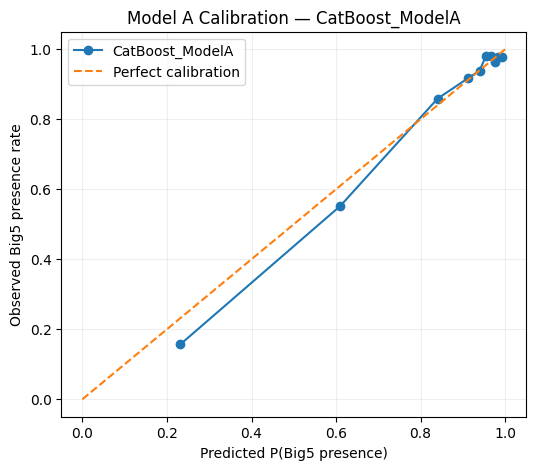

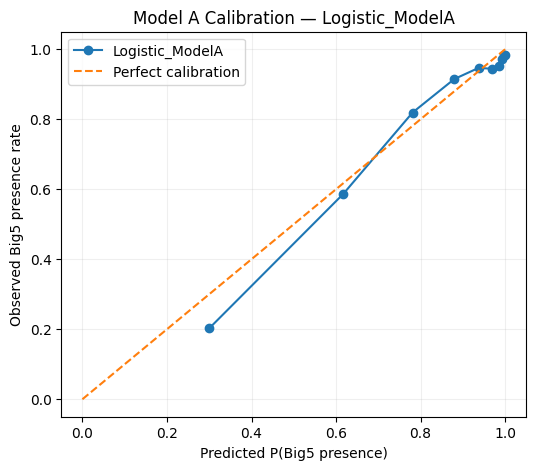

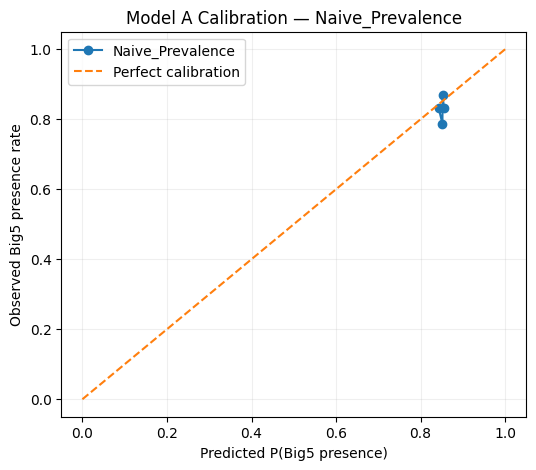

In [32]:
for model, g in (
    calibration_table
    .groupby(
        "model"
    )
):
    plt.figure(
        figsize=(
            6,
            5,
        )
    )

    plt.plot(
        g[
            "predicted_probability"
        ],
        g[
            "observed_rate"
        ],
        marker="o",
        label=model,
    )

    plt.plot(
        [
            0,
            1,
        ],
        [
            0,
            1,
        ],
        linestyle="--",
        label="Perfect calibration",
    )

    plt.xlabel(
        "Predicted P(Big5 presence)"
    )

    plt.ylabel(
        "Observed Big5 presence rate"
    )

    plt.title(
        f"Model A Calibration — {model}"
    )

    plt.legend()

    plt.grid(
        alpha=0.2
    )

    plt.show()

# Part L. Error / Slice Analysis

## 23. 실제 Big5 Exit 선수 중 모델이 놓친 사례

`matched_next=False`인데 높은 Presence probability를 준 선수를 봅니다.

이 선수들이 Model A의 어려운 사례입니다.

In [33]:
cat_pred = (
    predictions[
        predictions[
            "model"
        ].eq(
            "CatBoost_ModelA"
        )
    ]
    .copy()
)

false_presence_risk = (
    cat_pred[
        cat_pred[
            "matched_next"
        ].eq(False)
    ]
    .sort_values(
        "presence_probability",
        ascending=False,
    )
)

display(
    false_presence_risk[
        [
            "player",
            "season",
            "target_season",
            "team",
            "destination_team",
            "destination_in_big5",
            "transfer_event_preseason",
            "market_value_preseason_eur",
            "presence_probability",
            "threshold",
        ]
    ]
    .head(30)
)

,player,season,target_season,team,destination_team,destination_in_big5,transfer_event_preseason,market_value_preseason_eur,presence_probability,threshold
4786,Amine Gouiri,2021-2022,2022-2023,Nice,Nice,1,0,42000000.0,0.994929,0.57
5061,Hugo Guillamón,2021-2022,2022-2023,Valencia,Valencia,1,0,20000000.0,0.993363,0.57
5461,Rayan Aït Nouri,2021-2022,2022-2023,Wolves,Wolves,1,0,20000000.0,0.991248,0.57
5487,Rodri,2021-2022,2022-2023,Manchester City,Manchester City,1,0,80000000.0,0.990557,0.57
5125,Jens Petter Hauge,2021-2022,2022-2023,Eint Frankfurt,Eintracht Frankfurt,1,1,8000000.0,0.989261,0.57
4785,Amine Adli,2021-2022,2022-2023,Leverkusen,Leverkusen,1,0,12000000.0,0.988811,0.57
5070,Ibrahima Sissoko,2021-2022,2022-2023,Strasbourg,Strasbourg,1,0,8000000.0,0.988452,0.57
5102,Jakub Moder,2021-2022,2022-2023,Brighton,Brighton,1,0,12000000.0,0.988272,0.57
7593,Alexis Flips,2022-2023,2023-2024,Reims,Reims,1,0,6000000.0,0.986729,0.71
2443,Luiz Araújo,2020-2021,2021-2022,Lille,Lille,1,0,10000000.0,0.985084,0.66


## 24. 반대로 실제 Big5 Presence인데 낮게 본 사례

In [34]:
false_exit_risk = (
    cat_pred[
        cat_pred[
            "matched_next"
        ].eq(True)
    ]
    .sort_values(
        "presence_probability",
        ascending=True,
    )
)

display(
    false_exit_risk[
        [
            "player",
            "season",
            "target_season",
            "team",
            "destination_team",
            "destination_in_big5",
            "transfer_event_preseason",
            "market_value_preseason_eur",
            "presence_probability",
            "threshold",
        ]
    ]
    .head(30)
)

,player,season,target_season,team,destination_team,destination_in_big5,transfer_event_preseason,market_value_preseason_eur,presence_probability,threshold
2016,Bastian Oczipka,2020-2021,2021-2022,Schalke 04,Schalke 04,1,0,600000.0,0.080737,0.66
7993,Josuha Guilavogui,2022-2023,2023-2024,Wolfsburg,Without Club,0,1,2000000.0,0.111323,0.71
4930,Domen Črnigoj,2021-2022,2022-2023,Venezia,Venezia,1,0,1500000.0,0.122901,0.57
8312,Roger Martí,2022-2023,2023-2024,Elche,Elche,1,0,2000000.0,0.133867,0.71
5340,Mickaël Cuisance,2021-2022,2022-2023,Venezia,Venezia,1,0,NaN,0.135632,0.57
5417,Pablo Galdames Millán,2021-2022,2022-2023,Genoa,Genoa,1,0,NaN,0.136318,0.57
2460,Maranhão,2020-2021,2021-2022,Valladolid,Valladolid,1,0,50000.0,0.148265,0.66
2391,Kike Pérez,2020-2021,2021-2022,Valladolid,Valladolid,1,0,1000000.0,0.156865,0.66
5166,Josuha Guilavogui,2021-2022,2022-2023,Bordeaux,Bordeaux,1,0,3500000.0,0.168291,0.57
4868,Charalambos Lykogiannis,2021-2022,2022-2023,Cagliari,Cagliari,1,0,NaN,0.169332,0.57


## 25. Transfer / Destination Slice

Model A에서 외부 이적 정보가 실제로 어떤 확률을 만드는지 확인합니다.

In [35]:
slice_view = (
    cat_pred
    .groupby(
        [
            "transfer_event_preseason",
            "destination_in_big5",
        ],
        dropna=False,
    )
    .agg(
        n=(
            "player",
            "size",
        ),
        actual_presence_rate=(
            "matched_next",
            "mean",
        ),
        predicted_presence_mean=(
            "presence_probability",
            "mean",
        ),
    )
    .reset_index()
)

slice_view

,transfer_event_preseason,destination_in_big5,n,actual_presence_rate,predicted_presence_mean
0,0,1,3188,0.834065,0.845644
1,1,0,188,0.468085,0.539756
2,1,1,379,0.981530,0.946207


# Part M. 결과 저장

In [36]:
OUTPUTS = {
    "outer_results": (
        ARTIFACT_DIR
        / "09_01_model_a_outer_results.csv"
    ),

    "summary": (
        ARTIFACT_DIR
        / "09_01_model_a_summary.csv"
    ),

    "predictions": (
        ARTIFACT_DIR
        / "09_01_model_a_predictions.csv"
    ),

    "threshold_search": (
        ARTIFACT_DIR
        / "09_01_model_a_threshold_search.csv"
    ),

    "calibration": (
        ARTIFACT_DIR
        / "09_01_model_a_calibration.csv"
    ),

    "class_balance": (
        ARTIFACT_DIR
        / "09_01_model_a_class_balance.csv"
    ),
}


outer_results.to_csv(
    OUTPUTS[
        "outer_results"
    ],
    index=False,
)

model_summary.to_csv(
    OUTPUTS[
        "summary"
    ],
    index=False,
)

predictions.to_csv(
    OUTPUTS[
        "predictions"
    ],
    index=False,
)

threshold_search_results.to_csv(
    OUTPUTS[
        "threshold_search"
    ],
    index=False,
)

calibration_table.to_csv(
    OUTPUTS[
        "calibration"
    ],
    index=False,
)

class_balance.to_csv(
    OUTPUTS[
        "class_balance"
    ],
)


print("Saved:")
for name, path in (
    OUTPUTS.items()
):
    print(
        f"- {name:<18}",
        path.resolve(),
    )

Saved:
- outer_results      /content/drive/MyDrive/next_season_goal_prediction (1)/artifacts/09_01_model_a_outer_results.csv
- summary            /content/drive/MyDrive/next_season_goal_prediction (1)/artifacts/09_01_model_a_summary.csv
- predictions        /content/drive/MyDrive/next_season_goal_prediction (1)/artifacts/09_01_model_a_predictions.csv
- threshold_search   /content/drive/MyDrive/next_season_goal_prediction (1)/artifacts/09_01_model_a_threshold_search.csv
- calibration        /content/drive/MyDrive/next_season_goal_prediction (1)/artifacts/09_01_model_a_calibration.csv
- class_balance      /content/drive/MyDrive/next_season_goal_prediction (1)/artifacts/09_01_model_a_class_balance.csv


## 26. Protocol 저장

In [37]:
MODEL_A_PROTOCOL = {
    "stage": (
        "09-01 Model A "
        "Next-season Big5 Presence"
    ),

    "target": (
        "matched_next"
    ),

    "positive_class": (
        "next-season Big5 record exists"
    ),

    "negative_class": (
        "next-season Big5 record does not exist"
    ),

    "data_min_target_year": (
        2017
    ),

    "population": (
        "all development rows"
    ),

    "outer_validation_seasons": (
        OUTER_VAL_SEASONS
    ),

    "models": [
        "Naive_Prevalence",
        "Logistic_ModelA",
        "CatBoost_ModelA",
    ],

    "numeric_features": (
        MODEL_A_NUMERIC
    ),

    "categorical_features": (
        MODEL_A_CATEGORICAL
    ),

    "model_a_specific_features": (
        MODEL_A_SPECIFIC_FEATURES
    ),

    "forbidden_features": sorted(
        FORBIDDEN_FEATURES
    ),

    "threshold_selection": (
        "last season inside each "
        "Outer Train; maximize Macro F1"
    ),

    "primary_probability_metrics": [
        "log_loss",
        "brier",
        "roc_auc",
        "pr_auc_exit",
    ],

    "test_input_season": (
        LOCKED_TEST_INPUT_SEASON
    ),

    "test_target_season": (
        LOCKED_TEST_TARGET_SEASON
    ),

    "test_status": (
        "LOCKED / NOT LOADED"
    ),
}

PROTOCOL_PATH = (
    ARTIFACT_DIR
    / "09_01_model_a_protocol.json"
)

with PROTOCOL_PATH.open(
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        MODEL_A_PROTOCOL,
        f,
        ensure_ascii=False,
        indent=2,
    )

print(
    PROTOCOL_PATH.resolve()
)

/content/drive/MyDrive/next_season_goal_prediction (1)/artifacts/09_01_model_a_protocol.json


# 27. 결과 해석 — 직접 작성

아래는 **의도적으로 비워둡니다.**

---

## A. 문제 난이도

1. 2017+ Big5 Presence 비율은 몇 %인가?
2. Naive Accuracy가 높아 보이는가?
3. Naive의 Balanced Accuracy / Exit Recall은 어떤가?
4. 따라서 Accuracy 단독 사용이 왜 위험한가?

### 내 해석

- Presence 비율:
- Exit 비율:
- Accuracy 주의점:

---

## B. Logistic vs CatBoost

확률 품질:

1. Log Loss 1위는?
2. Brier Score 1위는?
3. ROC-AUC 1위는?
4. Exit PR-AUC 1위는?

Threshold 분류:

5. Macro F1 1위는?
6. Exit Recall은?
7. Presence Recall은?
8. Threshold가 Fold마다 얼마나 움직이는가?

### 내 해석

- Probability 기준 best:
- Exit 탐지 기준 best:
- Threshold 안정성:
- Fold 안정성:
- Model A 최종 후보:

---

## C. Calibration

1. 예측 확률과 실제 presence rate가 가까운가?
2. 확률을 과대평가하는 구간이 있는가?
3. 확률을 과소평가하는 구간이 있는가?
4. 09-02 Soft Gate에 바로 써도 될 수준인가?
5. 별도 probability calibration이 필요한가?

### 내 해석

- Calibration 품질:
- 추가 calibration 필요 여부:

---

## D. Slice

1. `destination_in_big5=0`인 경우 실제 presence rate는?
2. confirmed transfer가 없는 선수는?
3. Model A가 놓치는 실제 exit 선수의 공통점은?
4. Model A가 잘못 exit로 보는 presence 선수의 공통점은?

### 내 해석

- Transfer signal:
- Market signal:
- 어려운 exit 유형:
- 어려운 presence 유형:

---

# 최종 결정

- Model A 최종 모델:
- Model A threshold:
- Soft probability 사용 가능 여부:
- Probability calibration 필요 여부:
- 다음 단계:

# 다음 단계 — 09-02 Two-stage Integration

09-01에서 Model A가 결정되면 다음 Notebook에서:

```text
Model A
P(Big5 presence)

×

Model B
E(goals | Big5 presence)

=

Two-stage expected next-season Big5 goals
```

을 만듭니다.

## 비교할 방식

### Soft Gate
```text
expected_goals
=
presence_probability
×
conditional_goal_prediction
```

### Hard Gate
```text
presence_probability < threshold
→ 0 goals

presence_probability >= threshold
→ Model B prediction
```

그리고 전체 선수 population에서:

- MAE
- RMSE
- 10+/15+/20+
- Big5 exit 선수
- retained 선수

를 비교합니다.

---

## 중요한 점

09-02가 되어야 처음으로:

> "다음 시즌 Big5에 남을지 모르는 실제 preseason 상황"

을 반영한 **전체 파이프라인 평가**가 가능해집니다.

Final Test는 그 이후에도 계속 잠급니다.